#### **Frequent Itemset mining technique for Basket Analysis in simple Point of Sale dataset**
See https://www.edureka.co/blog/apriori-algorithm/

Dataset POS_data.csv from Kaggle 


In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl

import numpy as np
import pandas as pd
import seaborn as sns
import mlxtend

In [17]:
file = './data/POS_data.csv'
df = pd.read_csv(file, header=0)
df

,Date,Time,Transaction,Item
0,10/30/2016,9:58:11,1,Bread
1,10/30/2016,10:05:34,2,Scandinavian
2,10/30/2016,10:05:34,2,Scandinavian
3,10/30/2016,10:07:57,3,Hot chocolate
4,10/30/2016,10:07:57,3,Jam
...,...,...,...,...
21288,4/9/2017,14:32:58,9682,Coffee
21289,4/9/2017,14:32:58,9682,Tea
21290,4/9/2017,14:57:06,9683,Coffee
21291,4/9/2017,14:57:06,9683,Pastry


In [18]:
# We create a new column time_stamp and two dataframes (one per year)
df['Time_stamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

df_2016 = df[df['Time_stamp'].dt.year == 2016]
df_2017 = df[df['Time_stamp'].dt.year == 2017]

In [19]:
df.head(10)

,Date,Time,Transaction,Item,Time_stamp
0,10/30/2016,9:58:11,1,Bread,2016-10-30 09:58:11
1,10/30/2016,10:05:34,2,Scandinavian,2016-10-30 10:05:34
2,10/30/2016,10:05:34,2,Scandinavian,2016-10-30 10:05:34
3,10/30/2016,10:07:57,3,Hot chocolate,2016-10-30 10:07:57
4,10/30/2016,10:07:57,3,Jam,2016-10-30 10:07:57
5,10/30/2016,10:07:57,3,Cookies,2016-10-30 10:07:57
6,10/30/2016,10:08:41,4,Muffin,2016-10-30 10:08:41
7,10/30/2016,10:13:03,5,Coffee,2016-10-30 10:13:03
8,10/30/2016,10:13:03,5,Pastry,2016-10-30 10:13:03
9,10/30/2016,10:13:03,5,Bread,2016-10-30 10:13:03


In [20]:
num_products = df.Item.nunique()
print('There are', num_products, 'unique products')

There are 95 unique products


In [21]:
products = df.Item.unique()
products

array(['Bread', 'Scandinavian', 'Hot chocolate', 'Jam', 'Cookies',
       'Muffin', 'Coffee', 'Pastry', 'Medialuna', 'Tea', 'NONE',
       'Tartine', 'Basket', 'Mineral water', 'Farm House', 'Fudge',
       'Juice', "Ella's Kitchen Pouches", 'Victorian Sponge', 'Frittata',
       'Hearty & Seasonal', 'Soup', 'Pick and Mix Bowls', 'Smoothies',
       'Cake', 'Mighty Protein', 'Chicken sand', 'Coke',
       'My-5 Fruit Shoot', 'Focaccia', 'Sandwich', 'Alfajores', 'Eggs',
       'Brownie', 'Dulce de Leche', 'Honey', 'The BART', 'Granola',
       'Fairy Doors', 'Empanadas', 'Keeping It Local', 'Art Tray',
       'Bowl Nic Pitt', 'Bread Pudding', 'Adjustment', 'Truffles',
       'Chimichurri Oil', 'Bacon', 'Spread', 'Kids biscuit', 'Siblings',
       'Caramel bites', 'Jammie Dodgers', 'Tiffin', 'Olum & polenta',
       'Polenta', 'The Nomad', 'Hack the stack', 'Bakewell',
       'Lemon and coconut', 'Toast', 'Scone', 'Crepes', 'Vegan mincepie',
       'Bare Popcorn', 'Muesli', 'Crisps', 'Pi

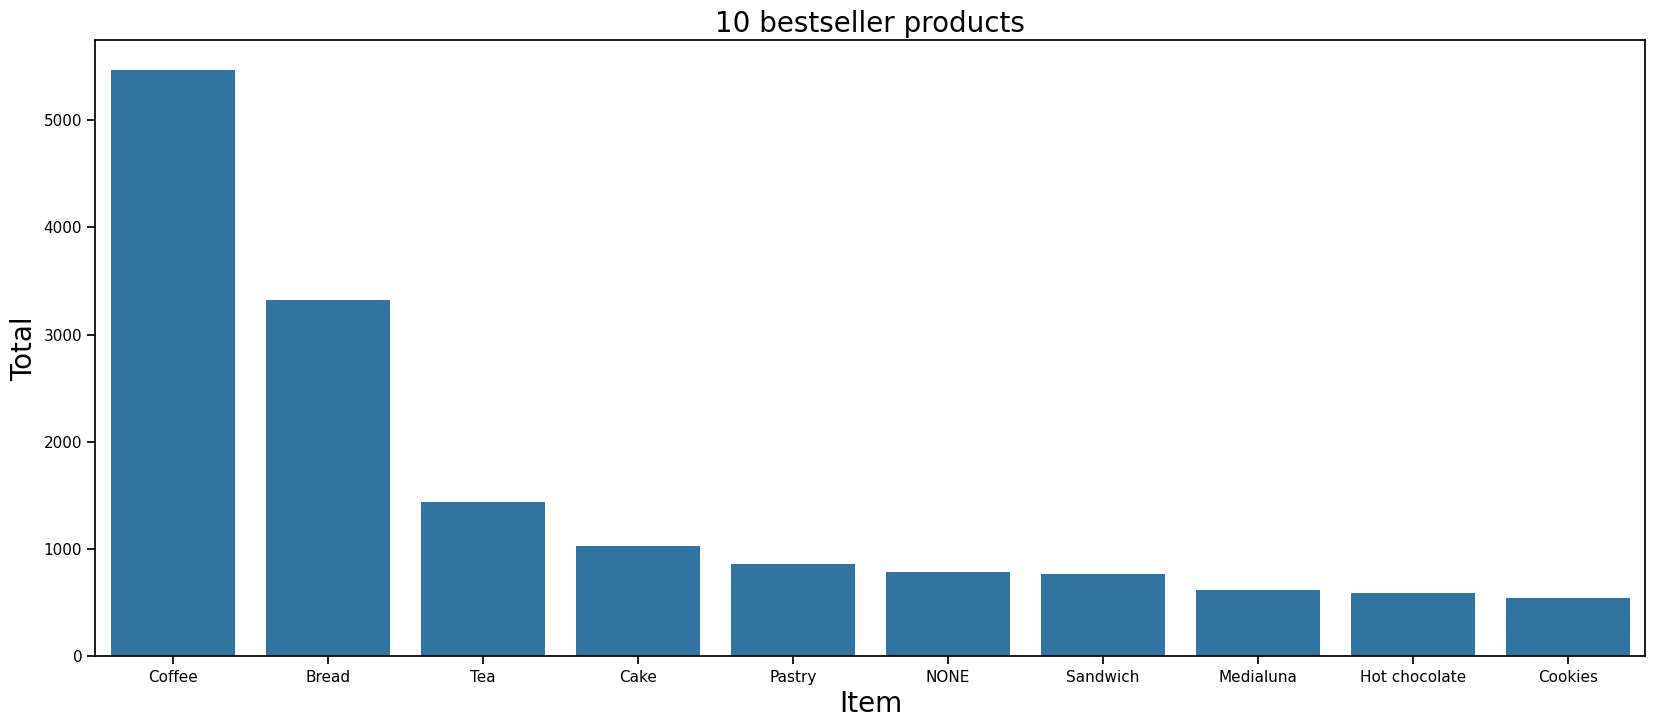

In [22]:
# Select 10 Top Sales and Analyze its patterns
df1 = df.groupby('Item', as_index=True).agg({'Item': 'count'}) \
                .rename(columns={'Item':'Total'})              \
                .reset_index()
df1 = df1.sort_values(by=['Total'], ascending=False)
plt.figure(figsize=(20,8))
df2 = df1.head(10)

sns.set_context("notebook", rc={"font.size":20,"axes.titlesize":20,"axes.labelsize":20})
sns.barplot(x='Item', y='Total', data=df2).set_title("10 bestseller products", size=20)

plt.show()

In [23]:
df

,Date,Time,Transaction,Item,Time_stamp
0,10/30/2016,9:58:11,1,Bread,2016-10-30 09:58:11
1,10/30/2016,10:05:34,2,Scandinavian,2016-10-30 10:05:34
2,10/30/2016,10:05:34,2,Scandinavian,2016-10-30 10:05:34
3,10/30/2016,10:07:57,3,Hot chocolate,2016-10-30 10:07:57
4,10/30/2016,10:07:57,3,Jam,2016-10-30 10:07:57
...,...,...,...,...,...
21288,4/9/2017,14:32:58,9682,Coffee,2017-04-09 14:32:58
21289,4/9/2017,14:32:58,9682,Tea,2017-04-09 14:32:58
21290,4/9/2017,14:57:06,9683,Coffee,2017-04-09 14:57:06
21291,4/9/2017,14:57:06,9683,Pastry,2017-04-09 14:57:06


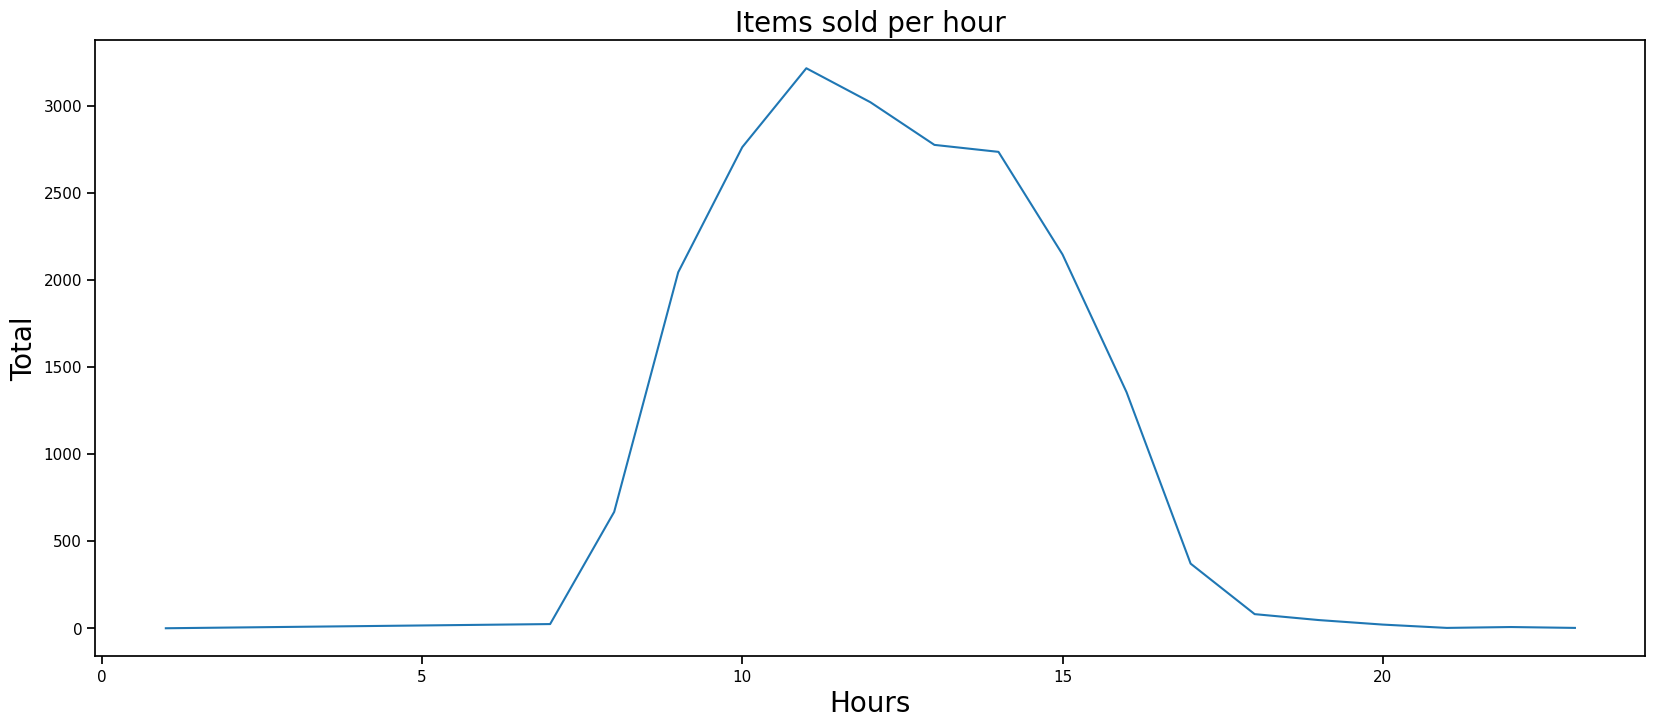

In [24]:
# Analyze shop hours Sales

times = df['Time_stamp']
times = pd.DatetimeIndex(df['Time_stamp'])
grouped = df.groupby([times.hour]).agg({'Item':'count'})                    \
                .rename(columns={'Item':'Total', 'Time_stamp': 'Hour'})     \
                .reset_index()
grouped = grouped.rename(columns={'Time_stamp': 'Hours'})  
plt.figure(figsize=(20,8))
sns.lineplot(x='Hours', y='Total', data=grouped).set_title("Items sold per hour", size=20)

plt.show()

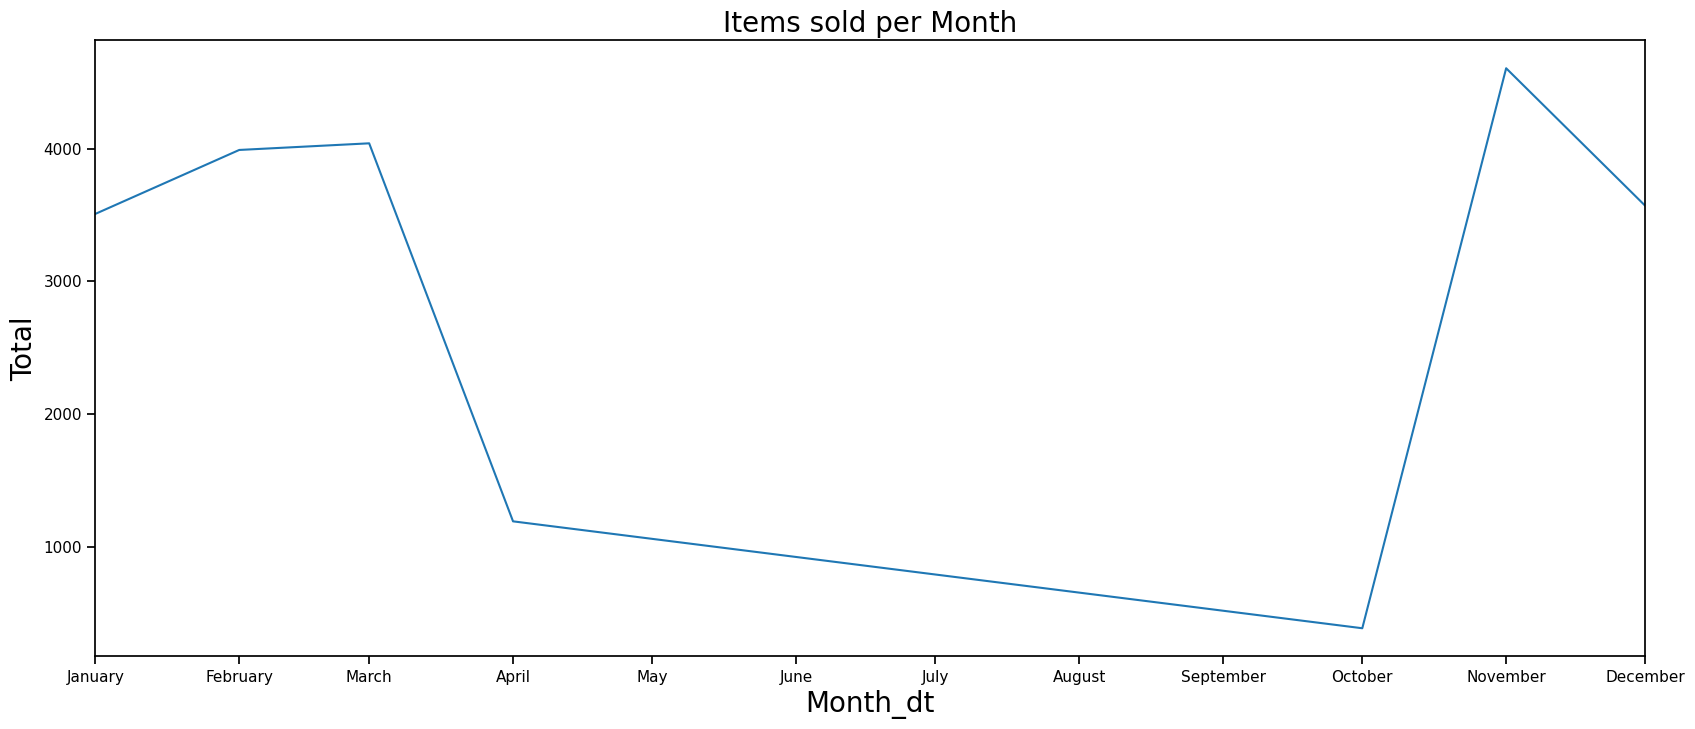

In [25]:
# Seasonality
# Creating season and month columns
# month 
from datetime import datetime
import datetime as dt
import matplotlib.dates as mdates

a = datetime.strptime(("2016-10-30 09:58:11"), '%Y-%m-%d %H:%M:%S')

df['Month_dt'] = df['Time_stamp'].dt.month

grouped_m = df.groupby([times.month]).agg({'Item':'count'})                 \
                .rename(columns={'Item':'Total', 'Time_stamp': 'Month'})     \
                .reset_index()
grouped_m = grouped_m.rename(columns={'Time_stamp': 'Month'}) 
grouped_m['Month_dt'] = pd.to_datetime(grouped_m['Month'], format='%m')
#df['Season']

fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111)

monthFmt = mdates.DateFormatter('%B')
ax.xaxis.set_major_formatter(monthFmt)
ax.set_xlim([dt.date(1900, 1, 1), dt.date(1900, 12, 1)])
sns.lineplot(x='Month_dt', y='Total', data=grouped_m).set_title("Items sold per Month", size=20)


plt.show()


In [26]:
df.Time_stamp

0       2016-10-30 09:58:11
1       2016-10-30 10:05:34
2       2016-10-30 10:05:34
3       2016-10-30 10:07:57
4       2016-10-30 10:07:57
                ...        
21288   2017-04-09 14:32:58
21289   2017-04-09 14:32:58
21290   2017-04-09 14:57:06
21291   2017-04-09 14:57:06
21292   2017-04-09 15:04:24
Name: Time_stamp, Length: 21293, dtype: datetime64[ns]

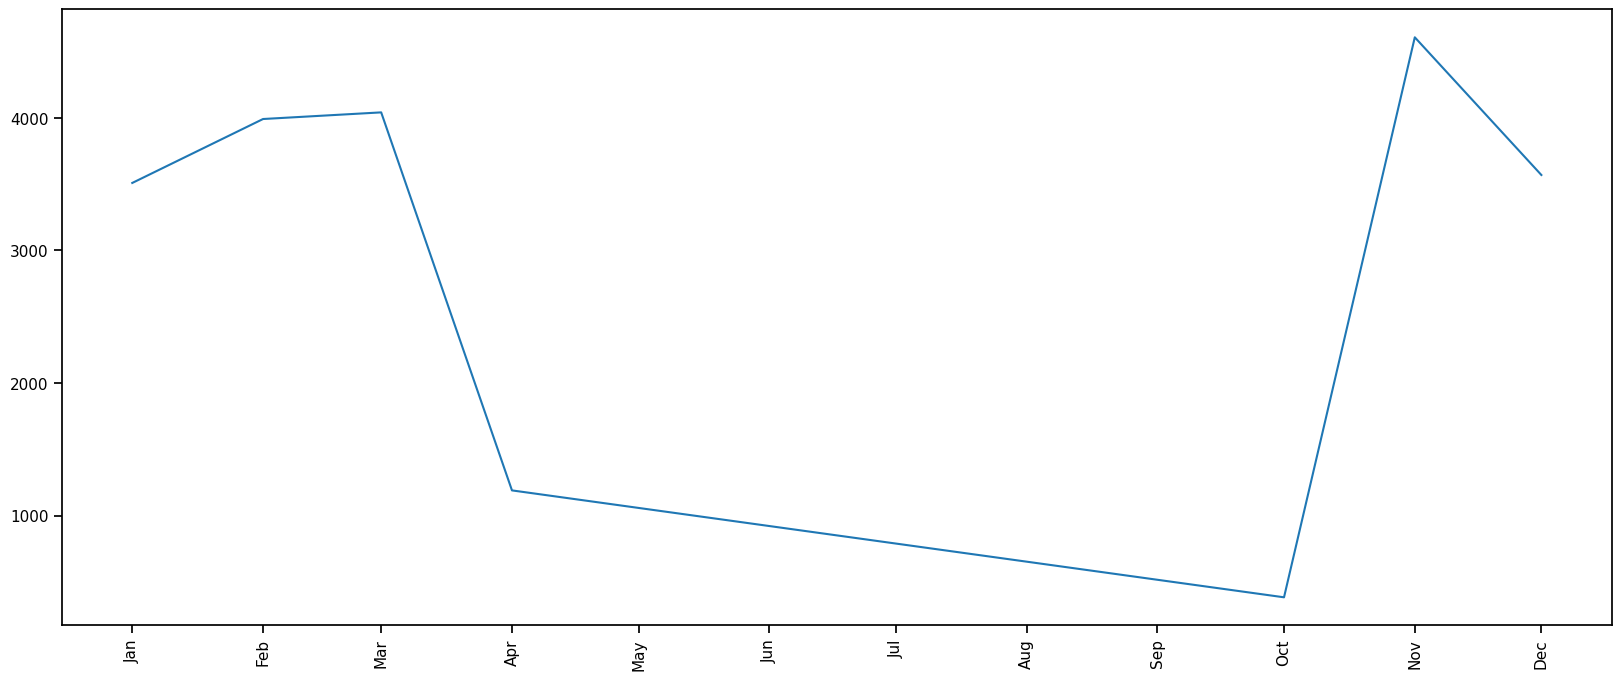

In [27]:
# Another plot example by months
from matplotlib.dates import MonthLocator, DateFormatter

grouped_m['Month'] = pd.to_datetime(grouped_m['Month'], format='%m')

fig = plt.figure(figsize=[20, 8])
ax = fig.add_subplot(111)
plt.plot(grouped_m.Month, grouped_m.Total)
plt.xticks(rotation='vertical')
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b'))

#### **Market Basket Analysis with Apriori**

In this final part we transform the point-of-sale data into a **basket matrix** and apply the **Apriori algorithm**.

The goal is to discover rules of the form:

\[
\{A\} 
ightarrow \{B\}
\]

which means: *when product A appears in a transaction, product B also tends to appear.*

We will use three key measures:

- **Support**: how frequently an itemset appears in all transactions.
- **Confidence**: how often the consequent appears when the antecedent appears.
- **Lift**: how much stronger the rule is compared with random co-occurrence.

A useful rule usually has reasonable support, high confidence, and lift greater than 1.


In [28]:
# Make sure the relevant columns exist
required_cols = {'Transaction', 'Item'}
missing_cols = required_cols - set(df.columns)

if missing_cols:
    raise ValueError(f"Missing columns needed for basket analysis: {missing_cols}")

# Keep only the columns needed for market basket analysis
basket_source = df[['Transaction', 'Item']].copy()

# Basic cleaning: remove missing values and normalize item names
basket_source = basket_source.dropna(subset=['Transaction', 'Item'])
basket_source['Item'] = basket_source['Item'].astype(str).str.strip()

print('Number of rows:', len(basket_source))
print('Number of transactions:', basket_source['Transaction'].nunique())
print('Number of unique items:', basket_source['Item'].nunique())

basket_source.head()

Number of rows: 21293
Number of transactions: 9531
Number of unique items: 95


,Transaction,Item
0,1,Bread
1,2,Scandinavian
2,2,Scandinavian
3,3,Hot chocolate
4,3,Jam


#### **1. Build the basket matrix**

Apriori needs one row per transaction and one column per product.

The value is:

- `True` if the item appears in the transaction
- `False` otherwise


In [29]:
# Create one-hot encoded transaction-item matrix
basket = (
    basket_source
    .assign(value=1)
    .pivot_table(
        index='Transaction',
        columns='Item',
        values='value',
        aggfunc='max',
        fill_value=0
    )
    .astype(bool)
)

print('Basket matrix shape:', basket.shape)
basket.head()

Basket matrix shape: (9531, 95)


Item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### **2. Apply Apriori**

`min_support` controls how frequent an itemset must be to be kept.

For a small dataset, `0.01` means: keep itemsets that appear in at least 1% of transactions.

If you get too many itemsets, increase `min_support`. If you get none, decrease it.


In [30]:
# If needed, install mlxtend first in a separate notebook cell:
# !pip install mlxtend

from mlxtend.frequent_patterns import apriori, association_rules

min_support = 0.01

frequent_itemsets = apriori(
    basket,
    min_support=min_support,
    use_colnames=True
)

# Add itemset length to help filtering later
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

frequent_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
).reset_index(drop=True)

print('Number of frequent itemsets:', len(frequent_itemsets))
frequent_itemsets.head(15)

Number of frequent itemsets: 63


,support,itemsets,length
0,0.475081,(Coffee),1
1,0.324940,(Bread),1
2,0.141643,(Tea),1
3,0.103137,(Cake),1
4,0.089393,"(Bread, Coffee)",2
5,0.085510,(Pastry),1
6,0.079005,(NONE),1
7,0.071346,(Sandwich),1
8,0.061379,(Medialuna),1
9,0.057916,(Hot chocolate),1


#### **3. Inspect frequent pairs and larger baskets**

Single products are useful, but the most interesting patterns usually begin with itemsets of length 2 or more.


In [31]:
frequent_pairs_or_more = frequent_itemsets[frequent_itemsets['length'] >= 2].copy()

frequent_pairs_or_more.head(20)

,support,itemsets,length
4,0.089393,"(Bread, Coffee)",2
10,0.054349,"(Cake, Coffee)",2
12,0.049523,"(Tea, Coffee)",2
13,0.047214,"(Coffee, Pastry)",2
14,0.042073,"(Coffee, NONE)",2
19,0.037981,"(Coffee, Sandwich)",2
21,0.034939,"(Medialuna, Coffee)",2
25,0.029378,"(Hot chocolate, Coffee)",2
26,0.028958,"(Bread, Pastry)",2
28,0.028014,"(Cookies, Coffee)",2


#### **4. Generate association rules**

Now we transform frequent itemsets into rules.

Example:

\[
\{Coffee\} 
ightarrow \{Cake\}
\]

Important metrics:

- **confidence**: among transactions containing the antecedent, how many also contain the consequent?
- **lift**: values above 1 mean the products appear together more often than expected by chance.


In [32]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.2
)

# Sort by lift first, then confidence and support
rules = rules.sort_values(
    by=['lift', 'confidence', 'support'],
    ascending=False
).reset_index(drop=True)

print('Number of rules:', len(rules))
rules.head(20)

Number of rules: 31


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(NONE),(Tea),0.079005,0.141643,0.018256,0.231076,1.631394,1.0,0.007066,1.116309,0.420228,0.090202,0.104190,0.179982
1,(Cake),(Tea),0.103137,0.141643,0.023607,0.228891,1.615972,1.0,0.008999,1.113146,0.425012,0.106736,0.101645,0.197779
2,(Toast),(Coffee),0.033365,0.475081,0.023502,0.704403,1.482699,1.0,0.007651,1.775789,0.336791,0.048464,0.436870,0.376936
3,(Sandwich),(Tea),0.071346,0.141643,0.014269,0.200000,1.412000,1.0,0.004164,1.072946,0.314202,0.071806,0.067987,0.150370
4,(Spanish Brunch),(Coffee),0.018046,0.475081,0.010807,0.598837,1.260494,1.0,0.002233,1.308493,0.210458,0.022406,0.235762,0.310792
5,(Medialuna),(Coffee),0.061379,0.475081,0.034939,0.569231,1.198175,1.0,0.005779,1.218561,0.176213,0.069665,0.179360,0.321387
6,(Pastry),(Coffee),0.085510,0.475081,0.047214,0.552147,1.162216,1.0,0.006590,1.172079,0.152626,0.091968,0.146815,0.325764
7,(Alfajores),(Coffee),0.036093,0.475081,0.019515,0.540698,1.138116,1.0,0.002368,1.142861,0.125899,0.039693,0.125003,0.290888
8,(Juice),(Coffee),0.038296,0.475081,0.020460,0.534247,1.124537,1.0,0.002266,1.127031,0.115155,0.041507,0.112713,0.288656
9,(NONE),(Coffee),0.079005,0.475081,0.042073,0.532537,1.120938,1.0,0.004539,1.122908,0.117145,0.082172,0.109455,0.310548


#### **5. Make the rules easier to read**

The raw output uses `frozenset`, which is correct but not very friendly for interpretation.

Here we convert antecedents and consequents into readable strings.


In [33]:
def itemset_to_string(itemset):
    return ', '.join(sorted(list(itemset)))

rules_readable = rules.copy()
rules_readable['antecedents'] = rules_readable['antecedents'].apply(itemset_to_string)
rules_readable['consequents'] = rules_readable['consequents'].apply(itemset_to_string)

rules_readable = rules_readable[[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift',
    'leverage',
    'conviction'
]]

rules_readable.head(20)

,antecedents,consequents,support,confidence,lift,leverage,conviction
0,NONE,Tea,0.018256,0.231076,1.631394,0.007066,1.116309
1,Cake,Tea,0.023607,0.228891,1.615972,0.008999,1.113146
2,Toast,Coffee,0.023502,0.704403,1.482699,0.007651,1.775789
3,Sandwich,Tea,0.014269,0.200000,1.412000,0.004164,1.072946
4,Spanish Brunch,Coffee,0.010807,0.598837,1.260494,0.002233,1.308493
5,Medialuna,Coffee,0.034939,0.569231,1.198175,0.005779,1.218561
6,Pastry,Coffee,0.047214,0.552147,1.162216,0.006590,1.172079
7,Alfajores,Coffee,0.019515,0.540698,1.138116,0.002368,1.142861
8,Juice,Coffee,0.020460,0.534247,1.124537,0.002266,1.127031
9,NONE,Coffee,0.042073,0.532537,1.120938,0.004539,1.122908


### 6. Filter for strong and interpretable rules

A practical rule should normally satisfy:

- enough **support** to matter commercially
- enough **confidence** to be reliable
- **lift > 1**, meaning the association is stronger than random chance

The thresholds below are examples. You should tune them depending on the size of your dataset.


In [34]:
strong_rules = rules_readable[
    (rules_readable['support'] >= 0.01) &
    (rules_readable['confidence'] >= 0.3) &
    (rules_readable['lift'] > 1.0)
].sort_values(
    by=['lift', 'confidence'],
    ascending=False
)

strong_rules.head(20)

,antecedents,consequents,support,confidence,lift,leverage,conviction
2,Toast,Coffee,0.023502,0.704403,1.482699,0.007651,1.775789
4,Spanish Brunch,Coffee,0.010807,0.598837,1.260494,0.002233,1.308493
5,Medialuna,Coffee,0.034939,0.569231,1.198175,0.005779,1.218561
6,Pastry,Coffee,0.047214,0.552147,1.162216,0.006590,1.172079
7,Alfajores,Coffee,0.019515,0.540698,1.138116,0.002368,1.142861
8,Juice,Coffee,0.020460,0.534247,1.124537,0.002266,1.127031
9,NONE,Coffee,0.042073,0.532537,1.120938,0.004539,1.122908
10,Sandwich,Coffee,0.037981,0.532353,1.120551,0.004086,1.122468
11,Cake,Coffee,0.054349,0.526958,1.109196,0.005350,1.109667
12,Scone,Coffee,0.017941,0.522936,1.100729,0.001642,1.100310


#### **7. Visualize the association rules**

This scatter plot helps interpret the trade-off between support, confidence and lift.

- x-axis: support
- y-axis: confidence
- point size: lift

Rules in the upper-right area with high lift are usually the most interesting.


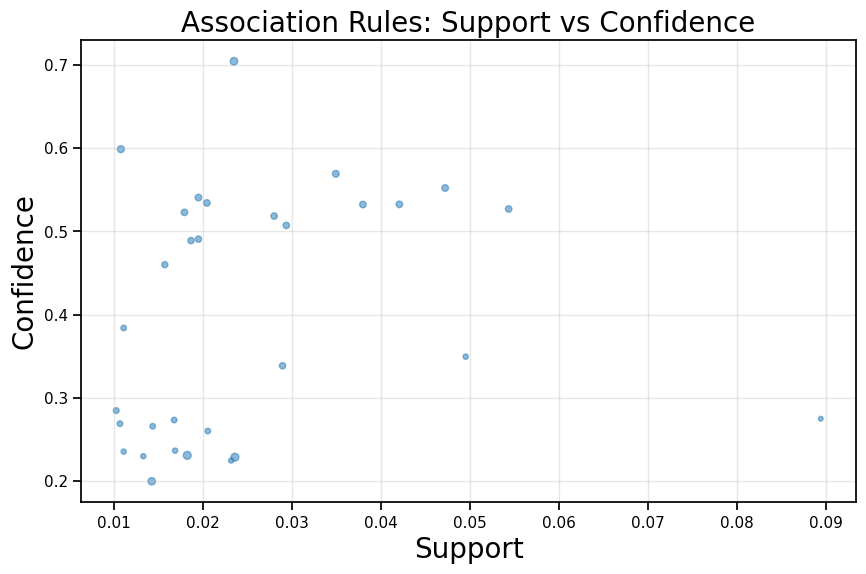

In [35]:
if len(rules) > 0:
    plt.figure(figsize=(10, 6))
    plt.scatter(
        rules['support'],
        rules['confidence'],
        s=rules['lift'] * 20,
        alpha=0.5
    )
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Association Rules: Support vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No rules found. Try lowering min_support or min_threshold.')

### 8. Business interpretation

Use the final rules to propose business actions.

For example:

- If `{A} -> {B}` has high confidence, place B near A.
- If lift is high, the products have a meaningful relationship.
- If support is too low, the rule may be interesting but commercially small.
- If confidence is high but lift is close to 1, the consequent may simply be popular in general.

A good interpretation should not only say *what the rule is*, but also *what action the store could take*.


In [36]:
# Print a few rules as plain-English recommendations
for _, row in strong_rules.head(10).iterrows():
    print(
        f"If a customer buys [{row['antecedents']}], "
        f"they also buy [{row['consequents']}] "
        f"with confidence={row['confidence']:.2f}, "
        f"support={row['support']:.3f}, "
        f"and lift={row['lift']:.2f}."
    )

If a customer buys [Toast], they also buy [Coffee] with confidence=0.70, support=0.024, and lift=1.48.
If a customer buys [Spanish Brunch], they also buy [Coffee] with confidence=0.60, support=0.011, and lift=1.26.
If a customer buys [Medialuna], they also buy [Coffee] with confidence=0.57, support=0.035, and lift=1.20.
If a customer buys [Pastry], they also buy [Coffee] with confidence=0.55, support=0.047, and lift=1.16.
If a customer buys [Alfajores], they also buy [Coffee] with confidence=0.54, support=0.020, and lift=1.14.
If a customer buys [Juice], they also buy [Coffee] with confidence=0.53, support=0.020, and lift=1.12.
If a customer buys [NONE], they also buy [Coffee] with confidence=0.53, support=0.042, and lift=1.12.
If a customer buys [Sandwich], they also buy [Coffee] with confidence=0.53, support=0.038, and lift=1.12.
If a customer buys [Cake], they also buy [Coffee] with confidence=0.53, support=0.054, and lift=1.11.
If a customer buys [Scone], they also buy [Coffee] wit

#### **9. Optional exercise for students**

Try changing the thresholds and observe how the number and quality of rules changes:

```python
min_support = 0.005
min_confidence = 0.4
```

Questions:

1. What happens when `min_support` increases?
2. What happens when `min_confidence` increases?
3. Which rule would you use for a product placement strategy?
4. Which rule would you use for a recommendation system?
5. Can you find a rule with high confidence but low lift? Why might that be misleading?


In [37]:
import session_info
session_info.show(html=False)

-----
matplotlib          3.10.8
mlxtend             0.23.4
numpy               2.2.6
pandas              2.3.3
seaborn             0.13.2
session_info        v1.0.1
-----
IPython             8.38.0
jupyter_client      8.8.0
jupyter_core        5.9.1
jupyterlab          4.5.3
notebook            7.5.3
-----
Python 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.35
-----
Session information updated at 2026-05-05 10:36
